# 5. Modelo base

**Issue:** [#5 Modelo BaseLine](https://github.com/velascocafe23/telco-churn-mlops/issues/5)

El objetivo es establecer las referencias mínimas de desempeño contra las que se juzgará
cualquier modelo de aprendizaje automático. Sin ellas no hay forma de afirmar que un
modelo aporta valor: un número aislado como 0.80 de exactitud no dice nada si no se sabe
qué se obtiene sin esfuerzo alguno.

Se establecen tres niveles de referencia, de menor a mayor exigencia:

1. **Clasificador trivial**, que ignora los atributos. Es el piso absoluto.
2. **Regla heurística**, la solución manual formulada en el análisis exploratorio.
3. **Modelo lineal simple**, primer aprendiz que usa todos los atributos.

El modelo definitivo deberá superar el tercero, no el primero.

## 5.1 Configuración

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

INTERMEDIATE_FILE = Path("../../data/02_intermediate/telco_customer_churn.parquet")
PREPROCESADOR_FILE = Path("../../models/preprocesador.joblib")

IDENTIFICADOR = "customerID"
OBJETIVO = "Churn"
CLASE_POSITIVA = "Yes"

PROPORCION_PRUEBA = 0.2
SEMILLA = 42
N_PLIEGUES = 5
UMBRAL_ANTIGUEDAD = 6
MAX_ITERACIONES = 1000

set_config(transform_output="default")
plt.rcParams["figure.dpi"] = 100

datos = pd.read_parquet(INTERMEDIATE_FILE)
preprocesador = joblib.load(PREPROCESADOR_FILE)

print(f"Datos cargados:  {datos.shape}")
print(
    f"Preprocesador:   {type(preprocesador).__name__} con {len(preprocesador.transformers)} ramas"
)

Datos cargados:  (7043, 21)
Preprocesador:   ColumnTransformer con 3 ramas


Una nota sobre la configuracion de salida de los transformadores. El notebook anterior
uso salida en formato DataFrame, comoda para inspeccionar los nombres de los atributos
generados. Aqui se usa la salida por defecto, en arreglos de NumPy.

El motivo es tecnico y vale la pena registrarlo. Con salida en DataFrame, cada rama del
`ColumnTransformer` devuelve un objeto con su propio indice y la concatenacion exige que
coincidan. La validacion cruzada entrega en cada pliegue un subconjunto con indices no
contiguos, y eso rompe la alineacion. No es un problema que se pueda resolver reindexando
antes, porque los subconjuntos los construye internamente el divisor de pliegues.

La salida en arreglos elimina el problema de raiz, y los nombres de atributos siguen
disponibles a traves de `get_feature_names_out`. Es la configuracion apropiada para
entrenamiento y para produccion, donde los lotes de entrada pueden venir indexados de
cualquier forma.

## 5.2 Partición de los datos

Se usa la misma semilla y la misma proporción que en el notebook anterior, de modo que
las particiones son idénticas y los resultados comparables entre etapas.

In [2]:
atributos = datos.drop(columns=[IDENTIFICADOR, OBJETIVO])
objetivo = (datos[OBJETIVO] == CLASE_POSITIVA).astype(int)

atributos_ent, atributos_pru, objetivo_ent, objetivo_pru = train_test_split(
    atributos,
    objetivo,
    test_size=PROPORCION_PRUEBA,
    random_state=SEMILLA,
    stratify=objetivo,
)

atributos_ent = atributos_ent.reset_index(drop=True)
atributos_pru = atributos_pru.reset_index(drop=True)
objetivo_ent = objetivo_ent.reset_index(drop=True)
objetivo_pru = objetivo_pru.reset_index(drop=True)

print(f"Entrenamiento: {atributos_ent.shape}, tasa positiva {objetivo_ent.mean():.4f}")
print(f"Prueba:        {atributos_pru.shape}, tasa positiva {objetivo_pru.mean():.4f}")

Entrenamiento: (5634, 19), tasa positiva 0.2654
Prueba:        (1409, 19), tasa positiva 0.2654


## 5.3 Estrategia de evaluación

Las métricas y su prioridad se definieron en el encuadre del problema. Se recogen aquí
porque determinan todas las comparaciones posteriores:

| Métrica | Uso |
|---|---|
| **Exhaustividad sobre la clase de fuga** | Métrica principal. Un cliente no detectado se pierde completo |
| **Precisión sobre la clase de fuga** | Restricción operativa. Determina cuánto presupuesto de retención se desperdicia |
| **F1 sobre la clase de fuga** | Métrica de comparación entre modelos, resume el equilibrio anterior |
| **ROC-AUC** | Capacidad de ordenamiento, que es lo que usa el equipo de retención al priorizar |
| **Exactitud balanceada** | Desempeño promedio en ambas clases, robusto al desbalance |
| Exactitud simple | Solo informativa. Descartada como criterio de decisión |

La validación cruzada es estratificada para que cada pliegue conserve la proporción de
cancelaciones del conjunto completo.

In [3]:
# El clasificador trivial mayoritario no predice ningun positivo, lo que deja la
# precision indefinida. Se declara explicitamente que en ese caso vale cero.
METRICAS = {
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
}

validacion = StratifiedKFold(n_splits=N_PLIEGUES, shuffle=True, random_state=SEMILLA)


def evaluar_con_validacion_cruzada(estimador, nombre: str) -> pd.DataFrame:
    """Ejecuta validacion cruzada y devuelve media y desviacion por metrica."""
    resultados = cross_validate(
        estimador,
        atributos_ent,
        objetivo_ent,
        cv=validacion,
        scoring=METRICAS,
        return_train_score=False,
    )
    filas = {
        metrica: {
            "media": resultados[f"test_{metrica}"].mean(),
            "desviacion": resultados[f"test_{metrica}"].std(),
        }
        for metrica in METRICAS
    }
    tabla = pd.DataFrame(filas).T.round(4)
    tabla.columns = pd.MultiIndex.from_product([[nombre], tabla.columns])
    return tabla


def medir_en_prueba(prediccion, nombre: str, puntajes=None) -> dict:
    """Calcula las metricas sobre el conjunto de prueba."""
    medicion = {
        "modelo": nombre,
        "precision": precision_score(objetivo_pru, prediccion, zero_division=0),
        "exhaustividad": recall_score(objetivo_pru, prediccion),
        "f1": f1_score(objetivo_pru, prediccion),
        "exactitud_balanceada": balanced_accuracy_score(objetivo_pru, prediccion),
        "exactitud": (prediccion == objetivo_pru).mean(),
    }
    medicion["roc_auc"] = (
        roc_auc_score(objetivo_pru, puntajes) if puntajes is not None else float("nan")
    )
    return medicion


print(f"Validación cruzada: {N_PLIEGUES} pliegues estratificados")

Validación cruzada: 5 pliegues estratificados


## 5.4 Referencia 1: clasificador trivial

Dos estrategias sin capacidad de aprendizaje. La primera predice siempre la clase
mayoritaria; la segunda asigna clases al azar respetando las proporciones observadas.

In [4]:
trivial_mayoritario = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", DummyClassifier(strategy="most_frequent")),
    ]
)

trivial_aleatorio = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", DummyClassifier(strategy="stratified", random_state=SEMILLA)),
    ]
)

cv_mayoritario = evaluar_con_validacion_cruzada(trivial_mayoritario, "mayoritario")
cv_aleatorio = evaluar_con_validacion_cruzada(trivial_aleatorio, "aleatorio")

pd.concat([cv_mayoritario, cv_aleatorio], axis=1)

mayoritario            aleatorio           
                        media desviacion     media desviacion
precision              0.0000     0.0000    0.2748     0.0248
recall                 0.0000     0.0000    0.2776     0.0250
f1                     0.0000     0.0000    0.2762     0.0249
roc_auc                0.5000     0.0000    0.5065     0.0171
balanced_accuracy      0.5000     0.0000    0.5065     0.0171
accuracy               0.7346     0.0001    0.6139     0.0133

El clasificador mayoritario expone con claridad el problema de la exactitud como métrica:
alcanza un valor alto sin detectar una sola cancelación, y su exhaustividad y F1 son cero.
Su desviación estándar es prácticamente nula porque no aprende nada, de modo que todos los
pliegues producen el mismo resultado.

El clasificador aleatorio estratificado obtiene una exhaustividad cercana a la tasa base,
que es lo esperable al asignar etiquetas al azar respetando las proporciones.

## 5.5 Referencia 2: regla heurística

> Cliente en riesgo: contrato mes a mes y antigüedad menor o igual a seis meses.

Esta regla no tiene parámetros que aprender, así que no se somete a validación cruzada:
su resultado no varía con el conjunto de entrenamiento porque no se entrena. Se evalúa
directamente sobre el conjunto de prueba, y de forma separada sobre el de entrenamiento
para verificar que su desempeño es estable entre particiones.

In [5]:
def aplicar_heuristica(conjunto: pd.DataFrame) -> pd.Series:
    """Marca como riesgo a clientes con contrato mes a mes y antiguedad baja."""
    return (
        (conjunto["Contract"] == "Month-to-month") & (conjunto["tenure"] <= UMBRAL_ANTIGUEDAD)
    ).astype(int)


heuristica_entrenamiento = aplicar_heuristica(atributos_ent)
heuristica_prueba = aplicar_heuristica(atributos_pru)

estabilidad = pd.DataFrame(
    [
        {
            "particion": "entrenamiento",
            "exhaustividad": recall_score(objetivo_ent, heuristica_entrenamiento),
            "precision": precision_score(objetivo_ent, heuristica_entrenamiento),
            "f1": f1_score(objetivo_ent, heuristica_entrenamiento),
        },
        {
            "particion": "prueba",
            "exhaustividad": recall_score(objetivo_pru, heuristica_prueba),
            "precision": precision_score(objetivo_pru, heuristica_prueba),
            "f1": f1_score(objetivo_pru, heuristica_prueba),
        },
    ]
).round(4)

estabilidad

,particion,exhaustividad,precision,f1
0,entrenamiento,0.4080,0.5437,0.4662
1,prueba,0.4545,0.5842,0.5113


## 5.6 Referencia 3: modelo lineal

Primer aprendiz que usa todos los atributos. Se evalúan dos variantes, y la comparación
entre ellas es instructiva: la diferencia está únicamente en si el entrenamiento compensa
el desbalance de clases.

In [6]:
lineal_simple = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", LogisticRegression(max_iter=MAX_ITERACIONES, random_state=SEMILLA)),
    ]
)

lineal_ponderado = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "modelo",
            LogisticRegression(
                max_iter=MAX_ITERACIONES,
                class_weight="balanced",
                random_state=SEMILLA,
            ),
        ),
    ]
)

cv_simple = evaluar_con_validacion_cruzada(lineal_simple, "lineal")
cv_ponderado = evaluar_con_validacion_cruzada(lineal_ponderado, "lineal ponderado")

pd.concat([cv_simple, cv_ponderado], axis=1)

lineal            lineal ponderado           
                    media desviacion            media desviacion
precision          0.6680     0.0277           0.5199     0.0178
recall             0.5264     0.0287           0.7987     0.0383
f1                 0.5884     0.0239           0.6296     0.0219
roc_auc            0.8463     0.0113           0.8463     0.0113
balanced_accuracy  0.7159     0.0150           0.7661     0.0196
accuracy           0.8048     0.0104           0.7508     0.0140

## 5.7 Comparación de todas las referencias sobre el conjunto de prueba

In [7]:
mediciones = []

for nombre, modelo in [
    ("trivial mayoritario", trivial_mayoritario),
    ("trivial aleatorio", trivial_aleatorio),
    ("lineal", lineal_simple),
    ("lineal ponderado", lineal_ponderado),
]:
    modelo.fit(atributos_ent, objetivo_ent)
    prediccion = modelo.predict(atributos_pru)
    probabilidad = modelo.predict_proba(atributos_pru)[:, 1]
    mediciones.append(medir_en_prueba(prediccion, nombre, probabilidad))

mediciones.append(medir_en_prueba(heuristica_prueba, "heurística"))

comparacion = pd.DataFrame(mediciones).set_index("modelo").round(4)
comparacion.sort_values("f1", ascending=False)

,precision,exhaustividad,f1,exactitud_balanceada,exactitud,roc_auc
modelo,,,,,,
lineal ponderado,0.5095,0.7914,0.6199,0.7580,0.7424,0.8442
lineal,0.6495,0.5401,0.5898,0.7174,0.8006,0.8441
heurística,0.5842,0.4545,0.5113,0.6688,0.7693,NaN
trivial aleatorio,0.2891,0.2914,0.2903,0.5163,0.6217,0.5163
trivial mayoritario,0.0000,0.0000,0.0000,0.5000,0.7346,0.5000


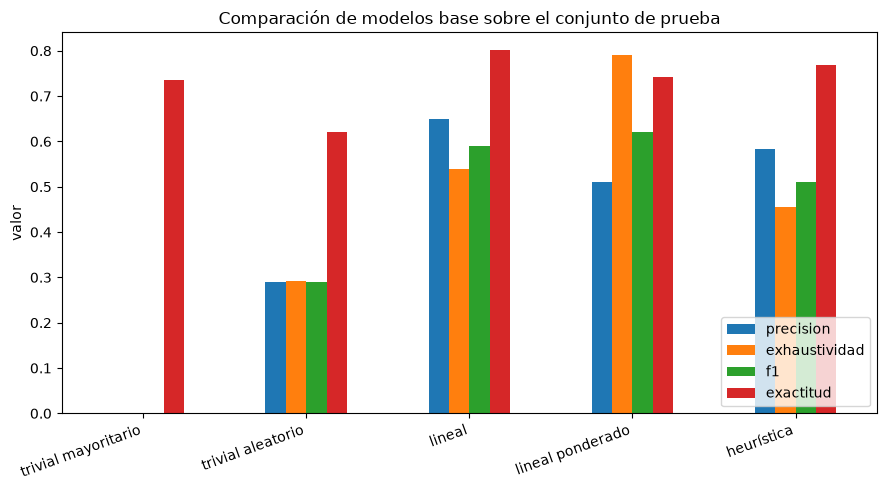

In [8]:
figura, eje = plt.subplots(figsize=(9, 5))
columnas_grafica = ["precision", "exhaustividad", "f1", "exactitud"]
comparacion[columnas_grafica].plot.bar(ax=eje)
eje.set_title("Comparación de modelos base sobre el conjunto de prueba")
eje.set_ylabel("valor")
eje.set_xlabel("")
eje.legend(loc="lower right")
plt.xticks(rotation=20, ha="right")
figura.tight_layout()
plt.show()

In [9]:
for nombre, prediccion in [
    ("heurística", heuristica_prueba),
    ("lineal", lineal_simple.predict(atributos_pru)),
    ("lineal ponderado", lineal_ponderado.predict(atributos_pru)),
]:
    matriz = confusion_matrix(objetivo_pru, prediccion)
    print(f"\n{nombre}")
    print(f"  No detectadas (falsos negativos): {matriz[1, 0]}")
    print(f"  Detectadas (verdaderos positivos): {matriz[1, 1]}")
    print(f"  Contactos innecesarios (falsos positivos): {matriz[0, 1]}")


heurística
  No detectadas (falsos negativos): 204
  Detectadas (verdaderos positivos): 170
  Contactos innecesarios (falsos positivos): 121

lineal
  No detectadas (falsos negativos): 172
  Detectadas (verdaderos positivos): 202
  Contactos innecesarios (falsos positivos): 109

lineal ponderado
  No detectadas (falsos negativos): 78
  Detectadas (verdaderos positivos): 296
  Contactos innecesarios (falsos positivos): 285


## 5.8 Selección del atributo más importante

El issue pide identificar la variable más importante y justificar la selección. La
justificación no puede apoyarse solo en una medida de asociación: se comprueba entrenando
un modelo con **un único atributo** y midiendo cuánto del desempeño total se conserva.

In [10]:
candidatos = ["Contract", "tenure", "InternetService", "PaymentMethod", "MonthlyCharges"]

resultados_individuales = []
for atributo in candidatos:
    es_numerico = atributo in atributos.select_dtypes(include="number").columns
    transformador = StandardScaler() if es_numerico else OneHotEncoder(handle_unknown="ignore")
    modelo_individual = Pipeline(
        steps=[
            (
                "preprocesamiento",
                ColumnTransformer([("unico", transformador, [atributo])]),
            ),
            (
                "modelo",
                LogisticRegression(
                    max_iter=MAX_ITERACIONES,
                    class_weight="balanced",
                    random_state=SEMILLA,
                ),
            ),
        ]
    )
    puntajes = cross_validate(
        modelo_individual,
        atributos_ent,
        objetivo_ent,
        cv=validacion,
        scoring=["f1", "roc_auc"],
    )
    resultados_individuales.append(
        {
            "atributo": atributo,
            "f1": round(puntajes["test_f1"].mean(), 4),
            "roc_auc": round(puntajes["test_roc_auc"].mean(), 4),
        }
    )

tabla_individuales = pd.DataFrame(resultados_individuales).sort_values("roc_auc", ascending=False)

f1_completo = cv_ponderado[("lineal ponderado", "media")]["f1"]
auc_completo = cv_ponderado[("lineal ponderado", "media")]["roc_auc"]

tabla_individuales["pct_del_f1_completo"] = (tabla_individuales["f1"] / f1_completo * 100).round(1)
tabla_individuales["pct_del_auc_completo"] = (
    tabla_individuales["roc_auc"] / auc_completo * 100
).round(1)

print(f"Modelo completo: F1 {f1_completo:.4f}, ROC-AUC {auc_completo:.4f}")
tabla_individuales.reset_index(drop=True)

Modelo completo: F1 0.6296, ROC-AUC 0.8463


,atributo,f1,roc_auc,pct_del_f1_completo,pct_del_auc_completo
0,Contract,0.5769,0.7395,91.6,87.4
1,tenure,0.5186,0.7352,82.4,86.9
2,InternetService,0.5256,0.6976,83.5,82.4
3,PaymentMethod,0.5107,0.6764,81.1,79.9
4,MonthlyCharges,0.4775,0.6235,75.8,73.7


## 5.9 Curva de aprendizaje

Muestra cómo evoluciona el desempeño al aumentar el volumen de datos de entrenamiento, y
permite distinguir dos situaciones distintas: un modelo limitado por falta de datos, en
cuyo caso las curvas siguen separándose al final, y un modelo limitado por su propia
capacidad, en cuyo caso ambas convergen a un valor bajo.

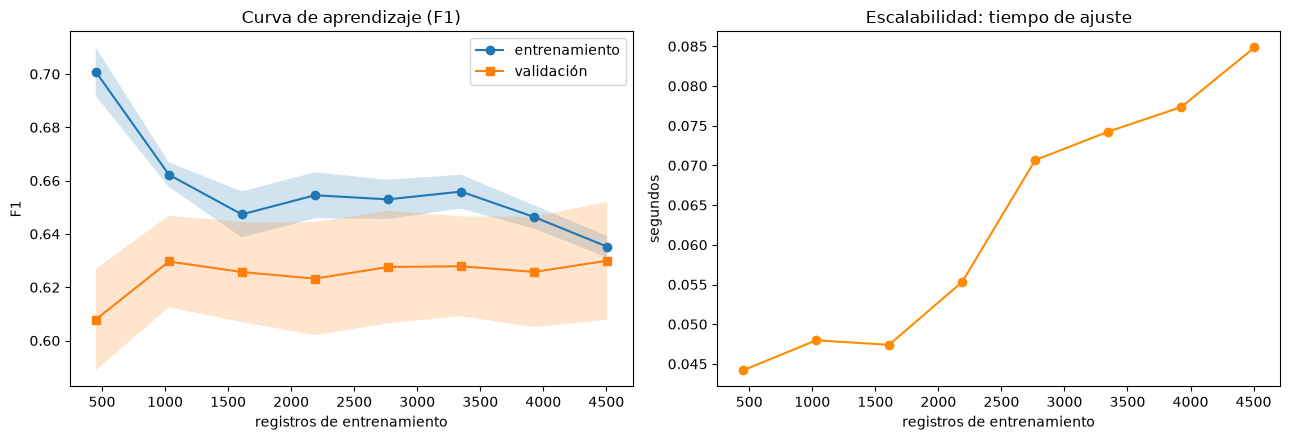

F1 entrenamiento final: 0.6352
F1 validación final:    0.6300
Brecha:                 0.0053


In [11]:
proporciones = np.linspace(0.1, 1.0, 8)

tamanos, puntaje_ent, puntaje_val, tiempos_ajuste, _ = learning_curve(
    lineal_ponderado,
    atributos_ent,
    objetivo_ent,
    train_sizes=proporciones,
    cv=validacion,
    scoring="f1",
    return_times=True,
    random_state=SEMILLA,
)

figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

ejes[0].plot(tamanos, puntaje_ent.mean(axis=1), marker="o", label="entrenamiento")
ejes[0].fill_between(
    tamanos,
    puntaje_ent.mean(axis=1) - puntaje_ent.std(axis=1),
    puntaje_ent.mean(axis=1) + puntaje_ent.std(axis=1),
    alpha=0.2,
)
ejes[0].plot(tamanos, puntaje_val.mean(axis=1), marker="s", label="validación")
ejes[0].fill_between(
    tamanos,
    puntaje_val.mean(axis=1) - puntaje_val.std(axis=1),
    puntaje_val.mean(axis=1) + puntaje_val.std(axis=1),
    alpha=0.2,
)
ejes[0].set_title("Curva de aprendizaje (F1)")
ejes[0].set_xlabel("registros de entrenamiento")
ejes[0].set_ylabel("F1")
ejes[0].legend()

ejes[1].plot(tamanos, tiempos_ajuste.mean(axis=1), marker="o", color="darkorange")
ejes[1].set_title("Escalabilidad: tiempo de ajuste")
ejes[1].set_xlabel("registros de entrenamiento")
ejes[1].set_ylabel("segundos")

figura.tight_layout()
plt.show()

brecha_final = puntaje_ent.mean(axis=1)[-1] - puntaje_val.mean(axis=1)[-1]
print(f"F1 entrenamiento final: {puntaje_ent.mean(axis=1)[-1]:.4f}")
print(f"F1 validación final:    {puntaje_val.mean(axis=1)[-1]:.4f}")
print(f"Brecha:                 {brecha_final:.4f}")

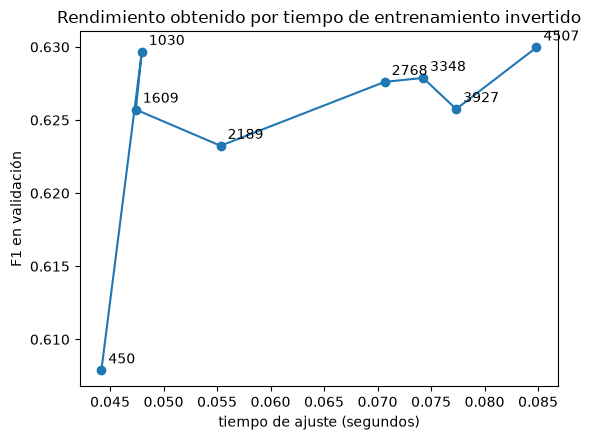

In [12]:
figura, eje = plt.subplots(figsize=(6, 4.5))
eje.plot(tiempos_ajuste.mean(axis=1), puntaje_val.mean(axis=1), marker="o")

for tiempo, puntaje, tamano in zip(
    tiempos_ajuste.mean(axis=1), puntaje_val.mean(axis=1), tamanos, strict=True
):
    eje.annotate(f"{tamano}", (tiempo, puntaje), textcoords="offset points", xytext=(5, 5))

eje.set_title("Rendimiento obtenido por tiempo de entrenamiento invertido")
eje.set_xlabel("tiempo de ajuste (segundos)")
eje.set_ylabel("F1 en validación")
figura.tight_layout()
plt.show()

## 5.10 Conclusiones y recomendaciones

### Referencias establecidas

| Referencia | F1 en prueba | Exhaustividad | Exactitud |
|---|---|---|---|
| Trivial mayoritario | 0.000 | 0.000 | 0.735 |
| Trivial aleatorio | 0.290 | 0.291 | 0.622 |
| Heuristica | 0.511 | 0.455 | 0.769 |
| Lineal | 0.590 | 0.540 | 0.801 |
| **Lineal ponderado** | **0.620** | **0.791** | 0.742 |

El clasificador trivial obtiene 0.735 de exactitud sin detectar una sola cancelacion, y
el modelo lineal ponderado obtiene 0.742, practicamente lo mismo, detectando el 79% de
ellas. Queda demostrado por que la exactitud no puede ser el criterio de decision.

**La referencia a superar es el modelo lineal ponderado: F1 de 0.620 sobre la clase de
fuga.**

### El hallazgo central: la ponderacion no mejora el modelo, mueve el umbral

Ambas variantes del modelo lineal obtienen exactamente el mismo ROC-AUC, 0.8463. El
ROC-AUC mide la capacidad de ordenar clientes por riesgo, y esa capacidad es identica con
y sin ponderacion. Lo unico que cambia es donde se corta ese ordenamiento.

El efecto operativo es grande: de 202 a 296 cancelaciones detectadas, a cambio de que los
contactos innecesarios pasen de 109 a 285. Cada cancelacion adicional detectada cuesta
aproximadamente dos contactos innecesarios de mas.

La consecuencia es que **la eleccion del umbral es una decision de negocio, no un
hiperparametro**. Depende de la capacidad de atencion del equipo de retencion y de la
relacion entre el valor de un cliente retenido y el costo de una oferta.

### El atributo mas importante

`Contract` entrenado en solitario alcanza un F1 de 0.577, el **91.6% del F1 del modelo
completo**, y un ROC-AUC de 0.740, el 87.4% del total. Los otros dieciocho atributos
aportan en conjunto menos del 9% restante del F1.

La justificacion no se apoya en una medida de asociacion sino en desempeno predictivo
real: un modelo que solo conoce el tipo de contrato del cliente ya resuelve la mayor
parte del problema.

### Lectura de la curva de aprendizaje

La brecha entre entrenamiento y validacion al usar todos los datos es de 0.0053, y ambas
curvas son planas desde tamanos pequenos.

Esto descarta el sobreajuste, pero dice algo mas relevante: **recolectar mas registros no
va a mejorar el desempeno**. El modelo esta limitado por la informacion contenida en los
atributos, no por el volumen de datos, lo que concuerda con el 6.1% de perfiles de
servicio con desenlace ambiguo detectado en el analisis exploratorio. La via de mejora es
obtener atributos nuevos, no mas filas.

### Recomendaciones para la seleccion de modelo

1. **Tratar la ponderacion de clases como hiperparametro a optimizar**, no fijarla de
   antemano. Su efecto sobre el equilibrio entre precision y exhaustividad es de primer
   orden.
2. **Probar modelos basados en arboles**. El analisis exploratorio mostro una interaccion
   fuerte entre contrato y antiguedad, que estos modelos capturan de forma natural y el
   modelo lineal solo aproxima.
3. **Optimizar el umbral de decision de forma explicita**, dado que el ROC-AUC identico
   entre variantes demuestra que ahi esta el margen real de maniobra.
4. **Usar F1 sobre la clase de fuga como criterio de seleccion**, con ROC-AUC como medida
   complementaria de capacidad de ordenamiento.
5. **Evaluar `drop="if_binary"` en la codificacion**. Las categorias binarias generan
   pares de indicadores redundantes que introducen colinealidad en los modelos lineales.
6. **Contrastar con pruebas estadisticas**. Las desviaciones entre pliegues rondan 0.02,
   del mismo orden que las diferencias entre modelos, de modo que comparar medias sin
   prueba formal no seria concluyente.
7. **No invertir en recolectar mas registros**, por lo que muestra la curva de
   aprendizaje.

**Siguiente paso:** seleccion del mejor modelo, con al menos cuatro familias distintas y
optimizacion de hiperparametros.